# Sistema de Recomendação por Imagens Digitais

Objetivo: Treinar uma rede de deep learning com 4 classes (camiseta, sapato, relógio, bolsa) usando transfer learning, e implementar um sistema de recomendação por similaridade visual com base na classe prevista.



In [44]:
# Importa bibliotecas
import os, glob, json, uuid, shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.applications import EfficientNetB0, efficientnet
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Constantes do projeto
IMG_SIZE = 224              # Tamanho padrão de entrada do modelo
CATALOG_DIR = "data/products"  # Pasta base do catálogo de imagens
EMB_PATH = "embeddings.npy"     # Arquivo para salvar embeddings
PATHS_PATH = "image_paths.json" # Arquivo para salvar lista de caminhos

In [45]:
# Cria as pastas para imagens
os.makedirs(f"{CATALOG_DIR}/camiseta", exist_ok=True)
os.makedirs(f"{CATALOG_DIR}/sapato", exist_ok=True)
os.makedirs(f"{CATALOG_DIR}/relogio", exist_ok=True)
os.makedirs(f"{CATALOG_DIR}/bolsa", exist_ok=True)

print("Pastas criadas com sucesso! Agora você pode enviar imagens para: camiseta, sapato, relogio e bolsa.")

Pastas criadas com sucesso! Agora você pode enviar imagens para: camiseta, sapato, relogio e bolsa.


In [46]:
# Importa as imagens para a pasta bolsa
from google.colab import files

def upload_to(subdir="bolsa"):
    target = f"{CATALOG_DIR}/{subdir}"
    os.makedirs(target, exist_ok=True)
    uploaded = files.upload()  # selecione múltiplas imagens do seu computador
    for name, data in uploaded.items():
        with open(os.path.join(target, name), "wb") as f:
            f.write(data)
    print(f"Enviadas {len(uploaded)} imagens para {target}")

# Exemplo: envie imagens de bolsas
upload_to("bolsa")

Enviadas 0 imagens para data/products/bolsa


In [47]:
# Importa as imagens para a pasta camiseta
from google.colab import files

def upload_to(subdir="camiseta"):
    target = f"{CATALOG_DIR}/{subdir}"
    os.makedirs(target, exist_ok=True)
    uploaded = files.upload()  # selecione múltiplas imagens do seu computador
    for name, data in uploaded.items():
        with open(os.path.join(target, name), "wb") as f:
            f.write(data)
    print(f"Enviadas {len(uploaded)} imagens para {target}")

# Exemplo: envie imagens de camiseta
upload_to("camiseta")

Enviadas 0 imagens para data/products/camiseta


In [48]:
# Importa as imagens para a pasta relogio
from google.colab import files

def upload_to(subdir="relogio"):
    target = f"{CATALOG_DIR}/{subdir}"
    os.makedirs(target, exist_ok=True)
    uploaded = files.upload()  # selecione múltiplas imagens do seu computador
    for name, data in uploaded.items():
        with open(os.path.join(target, name), "wb") as f:
            f.write(data)
    print(f"Enviadas {len(uploaded)} imagens para {target}")

# Exemplo: envie imagens de relogios
upload_to("relogio")

Enviadas 0 imagens para data/products/relogio


In [49]:
# Importa as imagens para a pasta sapato
from google.colab import files

def upload_to(subdir="sapato"):
    target = f"{CATALOG_DIR}/{subdir}"
    os.makedirs(target, exist_ok=True)
    uploaded = files.upload()  # selecione múltiplas imagens do seu computador
    for name, data in uploaded.items():
        with open(os.path.join(target, name), "wb") as f:
            f.write(data)
    print(f"Enviadas {len(uploaded)} imagens para {target}")

# Exemplo: envie imagens de sapatos
upload_to("sapato")

Enviadas 0 imagens para data/products/sapato


In [50]:
# Pasta com as imagens aumentadas salvas
AUG_DIR = f"{CATALOG_DIR}_augmented"
os.makedirs(AUG_DIR, exist_ok=True)

# Gerador de augmentação
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

def augment_images(category, n_aug=10):
    src_dir = f"{CATALOG_DIR}/{category}"
    dst_dir = f"{AUG_DIR}/{category}"
    os.makedirs(dst_dir, exist_ok=True)

    images = glob.glob(f"{src_dir}/*")
    for img_path in images:
        img = Image.open(img_path).resize((IMG_SIZE, IMG_SIZE))
        x = np.expand_dims(np.array(img), axis=0)
        x = datagen.flow(x, batch_size=1)
        for i in range(n_aug):
            batch = next(x)[0].astype(np.uint8)
            new_name = f"{uuid.uuid4().hex}.jpg"
            Image.fromarray(batch).save(os.path.join(dst_dir, new_name))
    print(f"Augmentadas {n_aug} imagens para cada original em '{category}'")

# Exemplo: aplicar em todas as categorias
for cat in ["camiseta", "sapato", "relogio", "bolsa"]:
    augment_images(cat, n_aug=5)

Augmentadas 5 imagens para cada original em 'camiseta'
Augmentadas 5 imagens para cada original em 'sapato'
Augmentadas 5 imagens para cada original em 'relogio'
Augmentadas 5 imagens para cada original em 'bolsa'


In [51]:
# Carregar modelo EfficientNetB0 sem a camada de classificação
base_model = EfficientNetB0(weights="imagenet", include_top=False, pooling="avg")
preprocess = efficientnet.preprocess_input

def load_and_preprocess(img_path, target_size=(IMG_SIZE, IMG_SIZE)):
    img = image.load_img(img_path, target_size=target_size)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess(x)
    return x

def embed_image(img_path):
    x = load_and_preprocess(img_path)
    emb = base_model.predict(x, verbose=0)
    return emb.squeeze()  # vetor 1D com 1280 números

In [52]:
# Carregar modelo EfficientNetB0 sem a camada de classificação
base_model = EfficientNetB0(weights="imagenet", include_top=False, pooling="avg")
preprocess = efficientnet.preprocess_input

def load_and_preprocess(img_path, target_size=(IMG_SIZE, IMG_SIZE)):
    img = image.load_img(img_path, target_size=target_size)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess(x)
    return x

def embed_image(img_path):
    x = load_and_preprocess(img_path)
    emb = base_model.predict(x, verbose=0)
    return emb.squeeze()

In [53]:
# Garantir que esta usando o diretório correto
CATALOG_DIR = "data/products_augmented"

# Listar todas as imagens
image_paths = glob.glob(f"{CATALOG_DIR}/*/*.jpg")
print(f"Total de imagens encontradas: {len(image_paths)}")

# Extrair embeddings
embeddings = []
paths = []

for path in image_paths:
    try:
        emb = embed_image(path)
        embeddings.append(emb)
        paths.append(path)
    except Exception as e:
        print(f"Erro ao processar {path}: {e}")

embeddings = np.array(embeddings)

# Salvar os resultados
np.save(EMB_PATH, embeddings)
with open(PATHS_PATH, "w") as f:
    json.dump(paths, f)

print(f"✅ Extraídos {len(embeddings)} embeddings e salvos com sucesso.")

Total de imagens encontradas: 240
✅ Extraídos 240 embeddings e salvos com sucesso.


In [54]:
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

def show_similar_images(query_path, top_k=5):
    query_emb = embed_image(query_path).reshape(1, -1)
    sims = cosine_similarity(query_emb, embeddings)[0]
    top_indices = np.argsort(sims)[::-1][:top_k]

    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(top_indices):
        img = Image.open(paths[idx])
        plt.subplot(1, top_k, i + 1)
        plt.imshow(img)
        plt.title(f"Score: {sims[idx]:.2f}")
        plt.axis("off")
    plt.suptitle("Imagens mais parecidas com a consulta")
    plt.show()

In [55]:
# Buscar imagens similares
def show_similar_images(query_path, top_k=5):
    query_emb = embed_image(query_path).reshape(1, -1)
    sims = cosine_similarity(query_emb, embeddings)[0]
    top_indices = np.argsort(sims)[::-1][:top_k]

    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(top_indices):
        img = Image.open(paths[idx])
        plt.subplot(1, top_k, i + 1)
        plt.imshow(img)
        plt.title(f"Score: {sims[idx]:.2f}")
        plt.axis("off")
    plt.suptitle("Imagens mais parecidas com a consulta")
    plt.show()


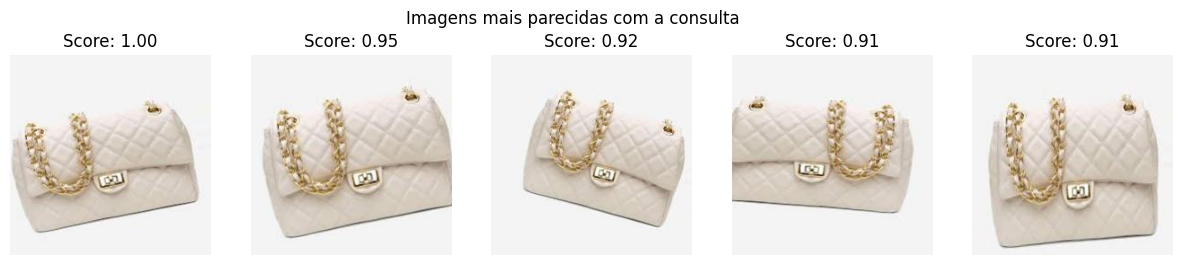

In [56]:
show_similar_images("data/products_augmented/bolsa/02ac97f3a1884cf09401c150ea41d811.jpg")

In [57]:
# Gerador com divisão entre treino e validação
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    "data/products_augmented",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=16,
    class_mode="categorical",
    subset="training"
)

val_gen = datagen.flow_from_directory(
    "data/products_augmented",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=16,
    class_mode="categorical",
    subset="validation"
)

Found 192 images belonging to 4 classes.
Found 48 images belonging to 4 classes.


In [58]:
# Montar o modelo com transfer learning
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False  # congelar base

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
output = Dense(4, activation="softmax")(x)  # 4 classes

model = Model(inputs=base.input, outputs=output)
model.compile(optimizer=Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])

In [59]:
# Treinar o modelo
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


12/12 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.2825 - loss: 1.4265 - val_accuracy: 0.2500 - val_loss: 1.3975
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.2393 - loss: 1.4330 - val_accuracy: 0.2500 - val_loss: 1.3886
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.2722 - loss: 1.3981 - val_accuracy: 0.2500 - val_loss: 1.3866
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.2961 - loss: 1.3999 - val_accuracy: 0.2500 - val_loss: 1.3899
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.2250 - loss: 1.4110 - val_accuracy: 0.2500 - val_loss: 1.3896
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.3024 - loss: 1.3932 - val_accuracy: 0.2500 - val_loss: 1.3887
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.2073 - loss: 1.4138 - val_accuracy: 0.2500 - val_loss: 1.3880
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.2246 - loss: 1.4226 - val_accuracy: 0.2500 - val_loss: 1.3890
Epo

In [60]:
# Classificar novas imagens
def classify_image(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)
    pred = model.predict(x)
    class_idx = np.argmax(pred)
    class_name = list(train_gen.class_indices.keys())[class_idx]
    print(f"Classe prevista: {class_name} (confiança: {pred[0][class_idx]:.2f})")

In [61]:
from google.colab import files
uploaded = files.upload()

Saving imagem_teste.jpeg to imagem_teste (2).jpeg


In [62]:
classify_image("imagem_teste (1).jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Classe prevista: bolsa (confiança: 0.27)


In [63]:
# Função que faz a recomendação por similaridade
def recommend_by_class_and_similarity(query_path, top_k=5):
    # Classificar a imagem
    img = image.load_img(query_path, target_size=(IMG_SIZE, IMG_SIZE))
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)
    pred = model.predict(x)
    class_idx = np.argmax(pred)
    class_name = list(train_gen.class_indices.keys())[class_idx]
    print(f"Classe prevista: {class_name}")

    # Filtrar imagens do catálogo pela mesma classe
    filtered_paths = [p for i, p in enumerate(paths) if f"/{class_name}/" in p]
    filtered_embs = [embeddings[i] for i, p in enumerate(paths) if f"/{class_name}/" in p]

    # Calcular similaridade
    query_emb = embed_image(query_path).reshape(1, -1)
    sims = cosine_similarity(query_emb, filtered_embs)[0]
    top_indices = np.argsort(sims)[::-1][:top_k]

    # Mostrar resultados
    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(top_indices):
        img = Image.open(filtered_paths[idx])
        plt.subplot(1, top_k, i + 1)
        plt.imshow(img)
        plt.title(f"Score: {sims[idx]:.2f}")
        plt.axis("off")
    plt.suptitle(f"Recomendações na classe '{class_name}'")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Classe prevista: bolsa


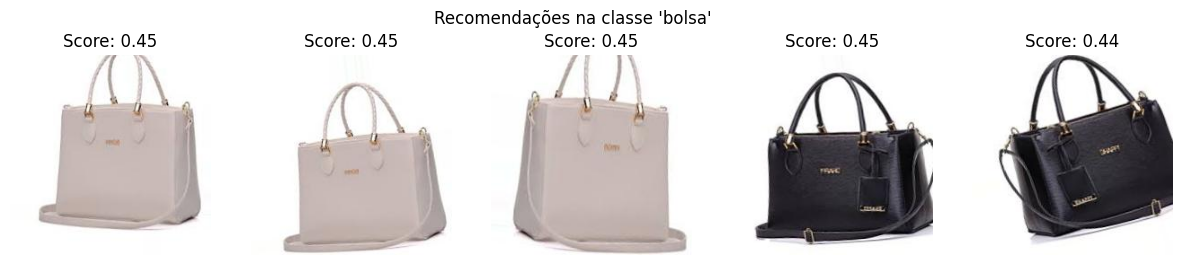

In [64]:
recommend_by_class_and_similarity("imagem_teste (1).jpeg")